
EDA.ipynb
======================
Exploratory Data Analysis and Data Cleaning for Freight Rate Data.

Steps covered:
- Loaded raw freight dataset and inspected shape, dtypes and sample rows
- Identified and removed rows with negative weight and negative posted_rate
- Dropped rows with missing values in market_index and weight (~1.4% of data)
- Detected and visualized outliers via boxplots for all numeric features
- Dropped redundant city string columns (pickup, delivery) since lat/lon fully represent location
- Dropped load_id (non-informative ID column)
- converted equipement data into OHE

Output:
- cleaned_freight_data.csv


# Import Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# load dataset

In [46]:
df = pd.read_csv('../dataset/train-test.csv')  # update filename
print(df.shape)
df.head(10)

(48000, 14)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28
5,TR-000006,Phoenix,Corpus Christi,28.75668,-115.87725,28.61374,-95.89569,1396.4,Flatbed,17018.0,2025-01-01,0.95167,1.92983,2676.98
6,TR-000007,Fresno,San Antonio,33.07921,-119.79528,29.50969,-98.40059,1502.6,Dry Van,19112.0,2025-01-01,0.95696,1.82074,2718.54
7,TR-000008,San Francisco,Kansas City,35.19670,-121.69849,39.41104,-91.12450,1976.9,Dry Van,29169.0,2025-01-01,0.97818,1.78430,3522.92
8,TR-000009,Bakersfield,Montgomery,33.28832,-116.67935,31.37602,-86.10743,2027.7,Dry Van,35018.0,2025-01-01,0.96534,1.79522,3675.27
9,TR-000010,Albuquerque,Phoenix,35.39918,-109.59792,28.75668,-115.87725,717.1,Flatbed,34671.0,2025-01-01,0.98475,2.17079,1578.83


# Data types and basic info

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [48]:
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


# missing counts for each column (numuraical)

In [49]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print(missing_df)

              missing_count  missing_pct
market_index            374     0.779167
weight                  300     0.625000
delivery                  0     0.000000
pickup_lat                0     0.000000
load_id                   0     0.000000
pickup                    0     0.000000
delivery_lat              0     0.000000
pickup_lon                0     0.000000
distance                  0     0.000000
delivery_lon              0     0.000000
equipment                 0     0.000000
date                      0     0.000000
quote_signal              0     0.000000
posted_rate               0     0.000000


# Missed Market index = Average market index of same day

In [50]:
# Market index → average of the same date
df["market_index"] = df["market_index"].fillna(
    df.groupby("date")["market_index"].transform("mean")
)

# Drop weight null rows entirely

In [51]:
before = len(df)

df = df.dropna(subset=['market_index', 'weight'])

after = len(df)
print(f"Rows removed: {before - after}")
print(f"Rows remaining: {after}")
print(f"% removed: {((before - after) / before) * 100:.2f}%")
print("\nMissing values remaining:\n", df.isnull().sum().sum())

Rows removed: 300
Rows remaining: 47700
% removed: 0.62%

Missing values remaining:
 0


# Investigate outliers using box plot

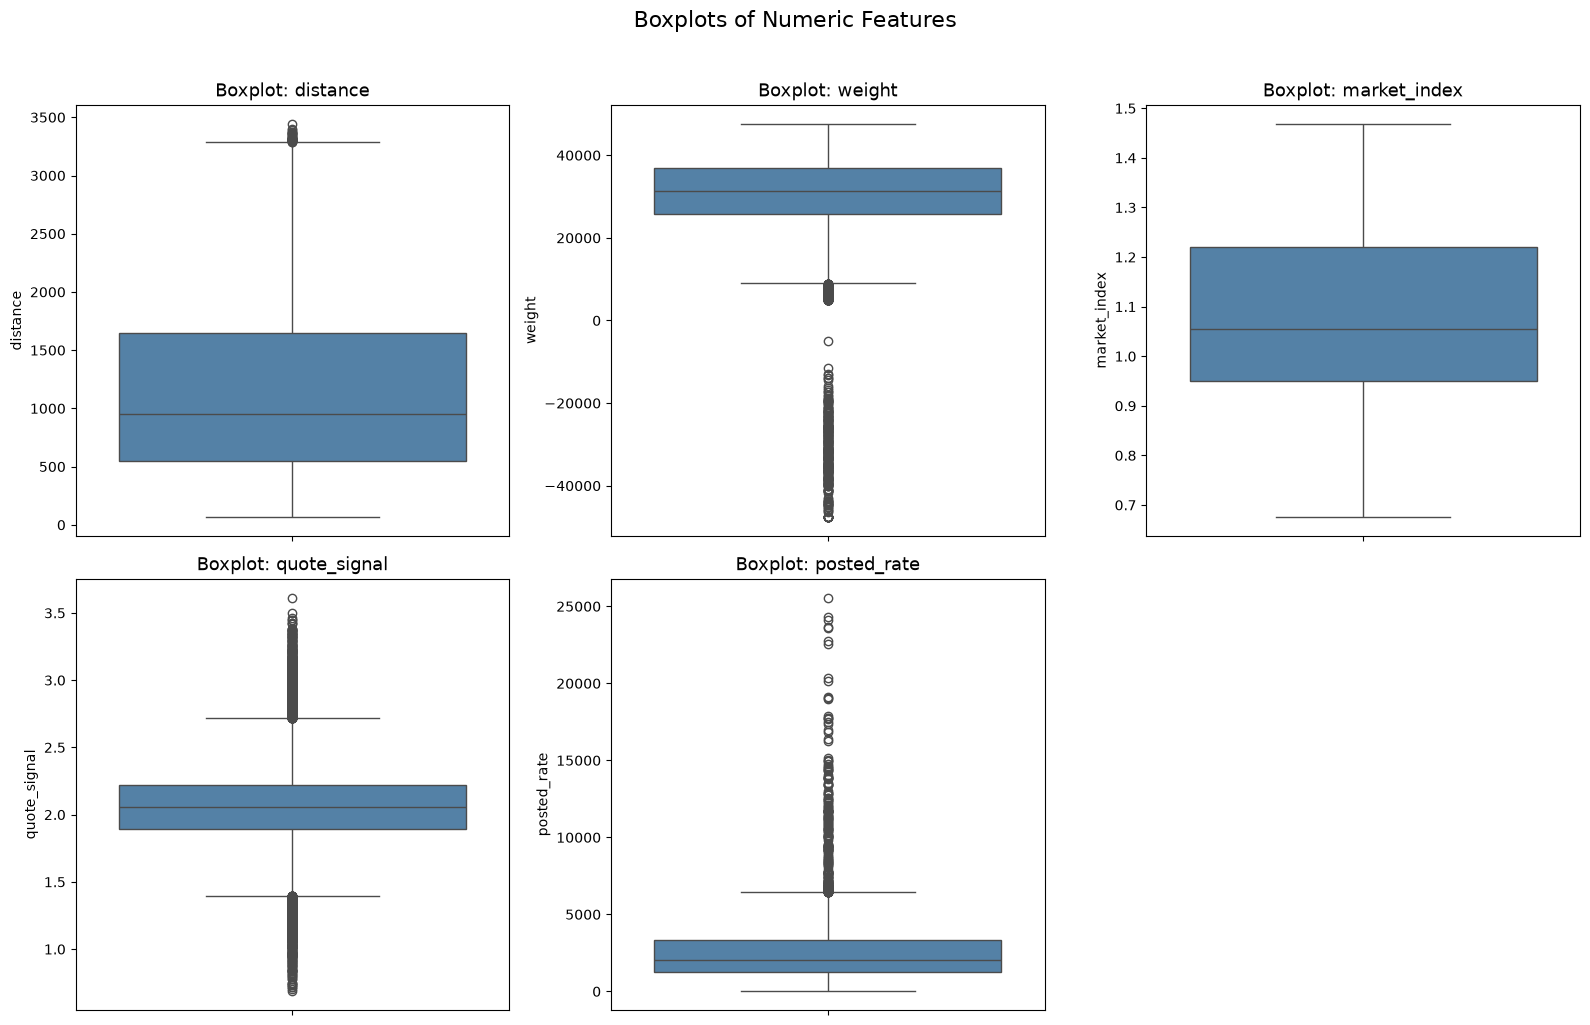

In [52]:
numeric_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot: {col}', fontsize=13)
    axes[i].set_ylabel(col)

# hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Boxplots of Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Outlier counts through IQR

In [53]:
numeric_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers | lower={lower:.2f}, upper={upper:.2f}")

distance: 32 outliers | lower=-1092.25, upper=3288.15
weight: 424 outliers | lower=8973.00, upper=53845.00
market_index: 0 outliers | lower=0.55, upper=1.62
quote_signal: 1940 outliers | lower=1.39, upper=2.72
posted_rate: 259 outliers | lower=-1866.59, upper=6448.88


In [54]:
# Check negative weights
print("Negative weight rows:", (df['weight'] < 0).sum())
print(df[df['weight'] < 0][['load_id','weight','equipment','distance']].head(10))

Negative weight rows: 292
        load_id   weight equipment  distance
68    TR-000069 -36559.0    Reefer    1334.2
204   TR-000205 -26670.0   Dry Van     496.2
206   TR-000207 -20003.0    Reefer     411.3
225   TR-000226 -23981.0    Reefer    1317.4
376   TR-000377 -41397.0   Dry Van    1331.1
446   TR-000447 -37215.0    Reefer    2438.3
495   TR-000496 -31214.0   Dry Van     715.9
641   TR-000642 -41023.0   Dry Van     582.4
806   TR-000807 -28320.0   Dry Van     676.1
1093  TR-001094 -25153.0   Dry Van    1058.5


In [55]:
# Are high rates tied to long distances?
high_rate = df[df['posted_rate'] > 6480]
print(f"High rate rows: {len(high_rate)}")
print(high_rate[['load_id','distance','weight','equipment','posted_rate']].head(10))


High rate rows: 248
        load_id  distance   weight equipment  posted_rate
469   TR-000470    2154.3  22509.0   Dry Van     10854.69
1329  TR-001330    1190.5  28538.0   Dry Van      7100.73
1466  TR-001467    2786.0  30322.0    Reefer     24140.21
1949  TR-001950    2794.2  35166.0    Reefer     13918.00
2030  TR-002031    1247.6  46843.0   Dry Van     10270.54
2221  TR-002222    1166.1  42165.0   Flatbed     11210.34
2223  TR-002224    1344.4  24751.0   Dry Van     12100.18
2514  TR-002515    1006.5  19892.0   Dry Van      9313.19
2662  TR-002663    1951.9  29933.0   Dry Van     10436.26
3028  TR-003029    1489.5  34450.0    Reefer      7679.26


# Outlier Treatment for extreme posted_rate values:
 Extreme posted_rate values above the upper IQR limit (6480) are replaced using the mean rate of loads with similar distance ranges and equipment types. Distance is divided into bins based on the distance distribution, with values above the 3500 upper IQR limit grouped into a 3500+ category. This preserves the relationship between distance, equipment, and pricing while reducing the influence of extreme values.

In [56]:

# Upper IQR limits
rate_upper_iqr =6448.88
distance_upper_iqr = 3288.15

# Create distance bins
df["distance_bin"] = pd.cut(
    df["distance"],
    bins=[0, 500, 1000, 1500, 2000, 2500, 3000, 3288.15, float("inf")],
    labels=[
        "0-500",
        "500-1000",
        "1000-1500",
        "1500-2000",
        "2000-2500",
        "2500-3000",
        "3000-3300",
        "3300+"
    ],
    include_lowest=True
)

# Calculate mean posted rate for each distance range + equipment
group_mean = (
    df[df["posted_rate"] <= rate_upper_iqr]
    .groupby(["distance_bin", "equipment"], observed=True)["posted_rate"]
    .mean()
)

# Identify extreme posted rates
extreme_mask = df["posted_rate"] > rate_upper_iqr

# Replace extreme rates with the typical rate
# for the same distance range + equipment
for idx in df.index[extreme_mask]:
    
    key = (
        df.loc[idx, "distance_bin"],
        df.loc[idx, "equipment"]
    )
    
    if key in group_mean.index:
        df.loc[idx, "posted_rate"] = group_mean.loc[key]
    else:
        # fallback if no matching group exists
        df.loc[idx, "posted_rate"] = df["posted_rate"].median()

# Remove helper column
df.drop(columns=["distance_bin"], inplace=True)

print(df[["load_id", "distance", "equipment", "posted_rate"]].head(20))

      load_id  distance equipment  posted_rate
0   TR-000001     274.3   Dry Van       645.41
1   TR-000002     280.5    Reefer       679.97
2   TR-000003     967.8   Dry Van      1802.54
3   TR-000004     965.4   Dry Van      1827.28
4   TR-000005     541.9    Reefer      1380.28
5   TR-000006    1396.4   Flatbed      2676.98
6   TR-000007    1502.6   Dry Van      2718.54
7   TR-000008    1976.9   Dry Van      3522.92
8   TR-000009    2027.7   Dry Van      3675.27
9   TR-000010     717.1   Flatbed      1578.83
10  TR-000011    2766.6   Dry Van      4744.15
11  TR-000012     549.0   Flatbed      1207.88
12  TR-000013    1085.1   Dry Van      2277.79
13  TR-000014    1145.3   Dry Van      2229.54
14  TR-000015     145.6   Dry Van       395.09
15  TR-000016     575.8   Dry Van      1165.80
16  TR-000017    1755.3    Reefer      3444.74
17  TR-000018    1706.0   Dry Van      3238.08
18  TR-000019     698.5   Dry Van      1441.82
19  TR-000020     108.2   Dry Van       305.70


# Outlier treatment for extreme distance values: 
get average value of same destinations and replace with outlier value

In [57]:
# Upper IQR limit for distance
upper = 3288.15

# Calculate mean distance for each pickup-delivery route
route_mean = (
    df[df["distance"] <= upper]
    .groupby(["pickup", "delivery"])["distance"]
    .mean()
)

# Identify upper outliers
outlier_mask = df["distance"] > upper

# Replace outliers with route average
df.loc[outlier_mask, "distance"] = df.loc[outlier_mask].apply(
    lambda row: route_mean.get(
        (row["pickup"], row["delivery"]),
        df["distance"].median()
    ),
    axis=1
)

print(f"Distance outliers handled: {outlier_mask.sum()}")

Distance outliers handled: 32


# Outlier handling for quate signal
Clip the values

In [58]:
lower = 1.39
upper = 2.72

df["quote_signal"] = df["quote_signal"].clip(
    lower=lower,
    upper=upper
)

# Drop negative weight and negative rate rows

In [59]:
before = len(df)

df = df[df['weight'] > 0]
df = df[df['posted_rate'] > 0]

after = len(df)
print(f"Rows removed: {before - after}")
print(f"Rows remaining: {after}")
print(f"% removed: {((before - after) / before) * 100:.2f}%")

Rows removed: 292
Rows remaining: 47408
% removed: 0.61%


In [60]:
print("Negative weights:", (df['weight'] < 0).sum())
print("Negative posted_rate:", (df['posted_rate'] < 0).sum())
print("\nShape after cleaning:", df.shape)

Negative weights: 0
Negative posted_rate: 0

Shape after cleaning: (47408, 14)


# Box Plot after 

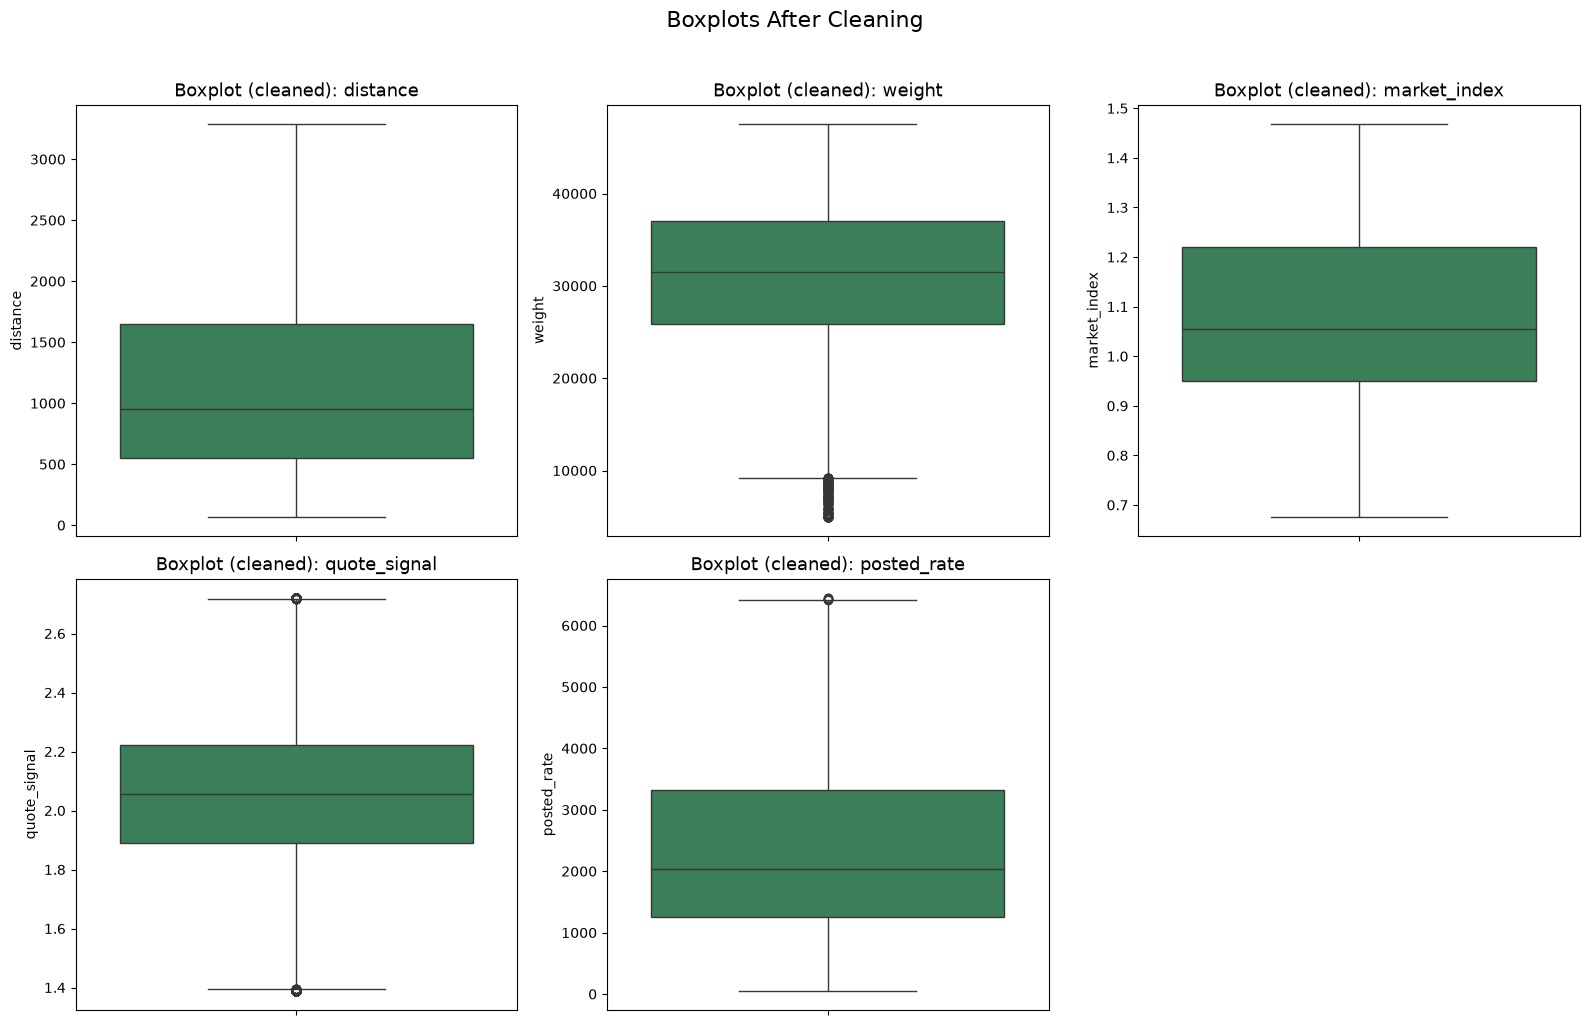

In [61]:
numeric_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='seagreen')
    axes[i].set_title(f'Boxplot (cleaned): {col}', fontsize=13)

axes[-1].set_visible(False)
plt.suptitle('Boxplots After Cleaning', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Remove unwated columns

In [62]:
# if lat/lon fully represent the city, city name is redundant
print(df.groupby('pickup')[['pickup_lat','pickup_lon']].nunique().max())
print(df.groupby('delivery')[['delivery_lat','delivery_lon']].nunique().max())

pickup_lat    1
pickup_lon    1
dtype: int64
delivery_lat    1
delivery_lon    1
dtype: int64


In [63]:
# Drop cities since lat/lon fully represent the location
df = df.drop(columns=['pickup', 'delivery'])
print("Shape after drop:", df.shape)
print(df.columns.tolist())

Shape after drop: (47408, 12)
['load_id', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']


In [64]:
# Drop load_id since it's a unique identifier and not useful for modeling
df = df.drop(columns=['load_id'])
print(df.shape)

(47408, 11)


# Convert date and equipement datas into numarical

In [65]:
#Date feature extraction
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['quarter'] = df['date'].dt.quarter
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)
df = df.drop(columns=['date'])


In [66]:
# one hot encoding for equipment
df = pd.get_dummies(df, columns=['equipment'], prefix='equip', drop_first=False)
print("Equipment columns created:", [c for c in df.columns if 'equip' in c])
print(df.shape)

Equipment columns created: ['equip_Dry Van', 'equip_Flatbed', 'equip_Reefer']
(47408, 16)


In [67]:
print(df.dtypes)
print("\nShape:", df.shape)
df.head()

pickup_lat       float64
pickup_lon       float64
delivery_lat     float64
delivery_lon     float64
distance         float64
weight           float64
market_index     float64
quote_signal     float64
posted_rate      float64
month              int32
day_of_week        int32
quarter            int32
is_weekend         int64
equip_Dry Van       bool
equip_Flatbed       bool
equip_Reefer        bool
dtype: object

Shape: (47408, 16)


,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate,month,day_of_week,quarter,is_weekend,equip_Dry Van,equip_Flatbed,equip_Reefer
0,38.09122,-76.78906,38.16908,-72.74564,274.3,30658.0,0.95684,2.39595,645.41,1,2,1,0,True,False,False
1,38.09122,-76.78906,39.22317,-72.96710,280.5,17555.0,0.97623,2.43355,679.97,1,2,1,0,False,False,True
2,39.22317,-72.96710,44.30296,-87.52871,967.8,31721.0,1.00971,1.84491,1802.54,1,2,1,0,True,False,False
3,39.55328,-72.18051,34.84933,-86.28940,965.4,32333.0,0.94518,1.87712,1827.28,1,2,1,0,True,False,False
4,31.83025,-94.38343,35.29479,-88.08915,541.9,35183.0,0.98480,2.56300,1380.28,1,2,1,0,False,False,True


In [68]:
df.to_csv('../dataset/processed/cleaned_freight_data.csv', index=False)
print("Saved! Shape:", df.shape)
print("Columns:", df.columns.tolist())

Saved! Shape: (47408, 16)
Columns: ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'posted_rate', 'month', 'day_of_week', 'quarter', 'is_weekend', 'equip_Dry Van', 'equip_Flatbed', 'equip_Reefer']
